# Imports

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## Load final cleaned dataset

In [58]:
df = pd.read_csv(
    "..\\data\\processed\\historical_model_ready_dataset.csv"
)

print(df.shape)

(3063, 202)


In [59]:
print(df.columns.tolist())

['GEO_ID', 'NAME', 'county_fips', 'B01001_001E', 'B01001_002E', 'B01001_003E', 'B01001_004E', 'B01001_005E', 'B01001_006E', 'B01001_007E', 'B01001_008E', 'B01001_009E', 'B01001_010E', 'B01001_011E', 'B01001_012E', 'B01001_013E', 'B01001_014E', 'B01001_015E', 'B01001_016E', 'B01001_017E', 'B01001_018E', 'B01001_019E', 'B01001_020E', 'B01001_021E', 'B01001_022E', 'B01001_023E', 'B01001_024E', 'B01001_025E', 'B01001_026E', 'B01001_027E', 'B01001_028E', 'B01001_029E', 'B01001_030E', 'B01001_031E', 'B01001_032E', 'B01001_033E', 'B01001_034E', 'B01001_035E', 'B01001_036E', 'B01001_037E', 'B01001_038E', 'B01001_039E', 'B01001_040E', 'B01001_041E', 'B01001_042E', 'B01001_043E', 'B01001_044E', 'B01001_045E', 'B01001_046E', 'B01001_047E', 'B01001_048E', 'B01001_049E', 'B02001_001E', 'B02001_002E', 'B02001_003E', 'B02001_004E', 'B02001_005E', 'B02001_006E', 'B02001_007E', 'B02001_008E', 'B02001_009E', 'B02001_010E', 'B15003_001E', 'B15003_002E', 'B15003_003E', 'B15003_004E', 'B15003_005E', 'B1500

## Remove targets

In [12]:
cluster_drop_cols = [
    "GEO_ID",
    "NAME",
    "county_fips",
    "state",
    "county_name",

    "target_2024_party_winner",
    "target_2024_dem_vote_share"
]

X_cluster = df.drop(
    columns=cluster_drop_cols,
    errors="ignore"
)

# keep only numeric columns
X_cluster = X_cluster.select_dtypes(
    include=["int64", "float64"]
)

print("Clustering feature matrix shape:", X_cluster.shape)
print("Non-numeric columns remaining:")
print(X_cluster.select_dtypes(exclude=["int64", "float64"]).columns.tolist())

Clustering feature matrix shape: (3063, 195)
Non-numeric columns remaining:
[]


## Scale

In [15]:
scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Scaling complete.")

Scaling complete.


## Determine Optimal Number of Clusters

In [18]:
inertia_values = []

K_values = range(2, 11)

for k in K_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_scaled)

    inertia_values.append(
        kmeans.inertia_
    )

# Elbow Method

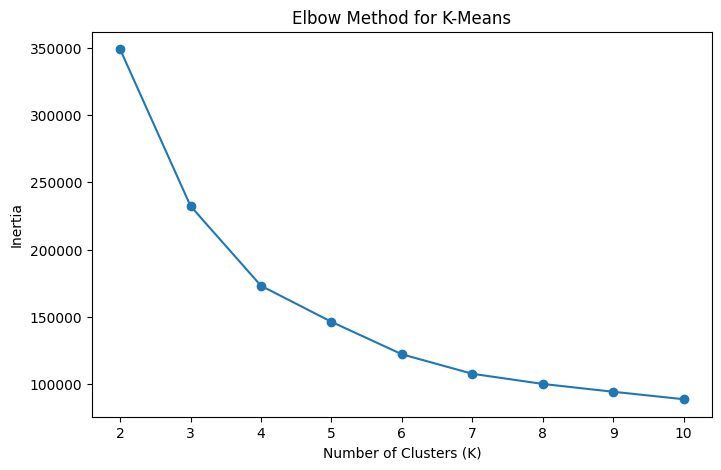

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    K_values,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method for K-Means")

plt.show()

# K-Means Clustering

In this section, K-Means clustering is applied to identify natural groupings of U.S. counties based on demographic, socioeconomic, and historical election characteristics.

The Elbow Method was used to determine an appropriate number of clusters. Based on the inertia curve, six clusters were selected for the final clustering solution.

The objective of this analysis is to explore whether counties naturally separate into distinct political and demographic groups.

## Train Final K-Means Model

In [ ]:
from sklearn.cluster import KMeans


kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    X_cluster_scaled
)

df["Cluster"] = cluster_labels

## Cluster Size Distribution

In [31]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    2885
1      19
2       1
3     158
Name: count, dtype: int64


## Visualization of Cluster Sizes

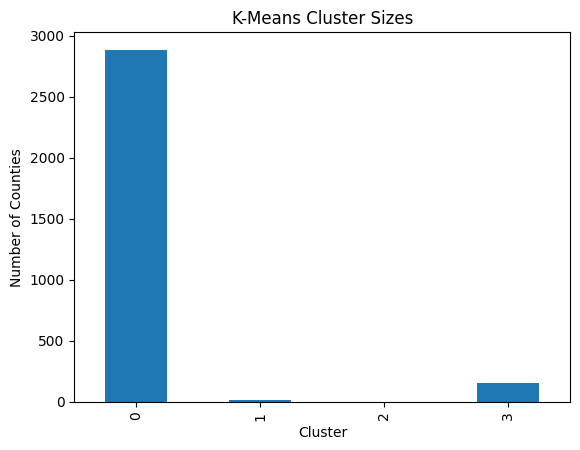

In [32]:
import matplotlib.pyplot as plt

cluster_counts.plot(
    kind="bar"
)

plt.title("K-Means Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Counties")
plt.show()

## PCA Visualization of Clusters

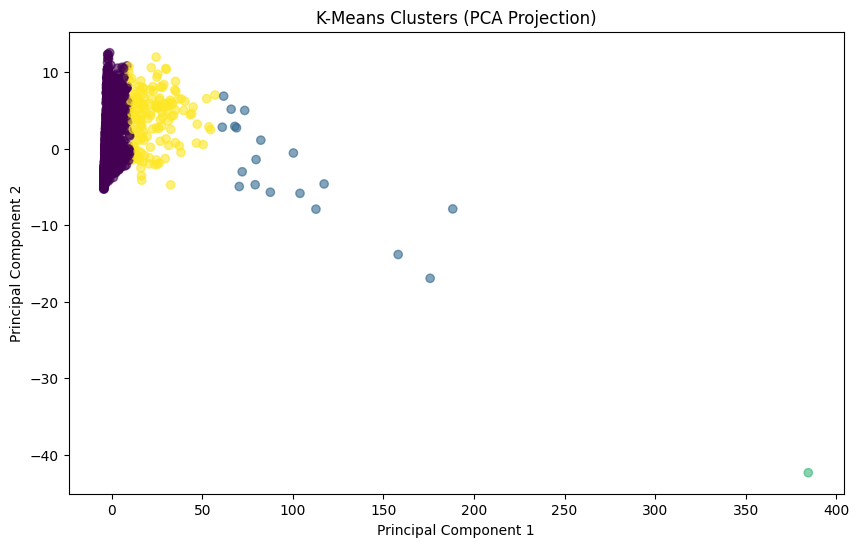

In [33]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_cluster_scaled
)

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    alpha=0.6
)

plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

## Cluster Summary Table

In [34]:
cluster_summary = df.groupby(
    "Cluster"
)[
    [
        "target_2024_dem_vote_share",
        "higher_education_rate",
        "poverty_rate",
        "white_pct",
        "black_pct",
        "asian_pct"
    ]
].mean()

display(cluster_summary)

,target_2024_dem_vote_share,higher_education_rate,poverty_rate,white_pct,black_pct,asian_pct
Cluster,,,,,,
0,0.346622,0.149364,0.141230,0.834250,0.085025,0.010208
1,0.651781,0.242675,0.139755,0.551079,0.156153,0.106862
2,0.648292,0.230829,0.139598,0.477576,0.080700,0.148259
3,0.593576,0.258344,0.113254,0.679165,0.141991,0.065995


## Reduced Feature Set for Clustering

The initial clustering attempt used all available numeric variables, including raw population count variables. This caused K-Means to create highly imbalanced clusters because very large counties dominated the clustering structure. To produce more interpretable clusters, this section uses a reduced set of percentage, rate, and political trend variables.

In [37]:
cluster_features = [
    "higher_education_rate",
    "poverty_rate",
    "unemployment_rate",
    "white_pct",
    "black_pct",
    "asian_pct",
    "target_2024_dem_vote_share",
    "avg_dem_share_2000_2020",
    "vote_volatility_2000_2020"
]

X_cluster = df[cluster_features]

print("Reduced clustering feature matrix shape:")
print(X_cluster.shape)

display(X_cluster.head())

Reduced clustering feature matrix shape:
(3063, 9)


,higher_education_rate,poverty_rate,unemployment_rate,white_pct,black_pct,asian_pct,target_2024_dem_vote_share,avg_dem_share_2000_2020,vote_volatility_2000_2020
0,0.192689,0.150865,0.028280,0.757562,0.195295,0.011664,0.263039,0.259270,0.019539
1,0.227387,0.090426,0.039053,0.854390,0.087741,0.009313,0.203961,0.224135,0.018666
2,0.082594,0.252218,0.069367,0.462998,0.476664,0.004875,0.421918,0.479025,0.025680
3,0.081076,0.167829,0.074359,0.765978,0.225485,0.002503,0.174895,0.267245,0.062940
4,0.091351,0.135867,0.051921,0.939676,0.013990,0.004086,0.091468,0.151475,0.070961


## Scale

In [38]:
scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Scaling complete.")

Scaling complete.


## Elbow Method using X_cluster_scaled

In [39]:
from sklearn.cluster import KMeans

inertia_values = []

K_values = range(2, 11)

for k in K_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_scaled)

    inertia_values.append(kmeans.inertia_)

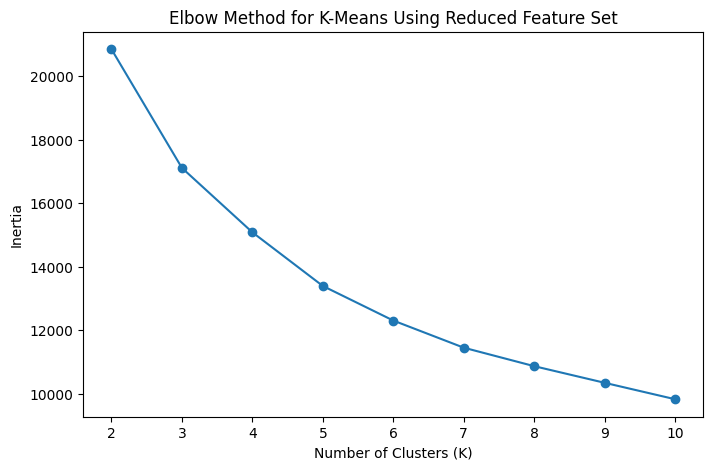

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    K_values,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Using Reduced Feature Set")

plt.show()

## Final K-Means Model

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    X_cluster_scaled
)

df["Cluster"] = cluster_labels

## Cluster Sizes

In [42]:
cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

Cluster
0     781
1    1066
2      74
3     411
4     731
Name: count, dtype: int64


## Cluster Size Plot

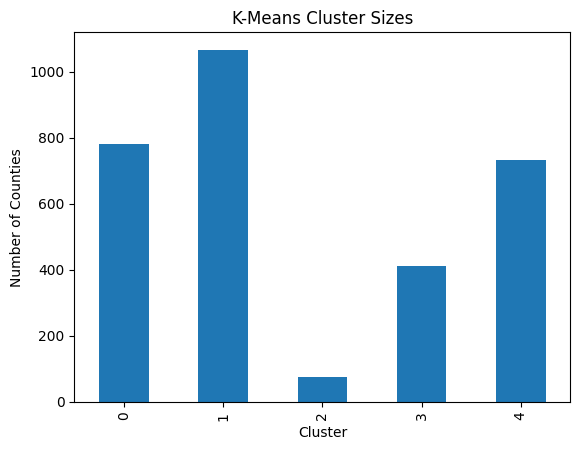

In [43]:
import matplotlib.pyplot as plt

cluster_counts.plot(
    kind="bar"
)

plt.title("K-Means Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Counties")

plt.show()

## PCA Visualization

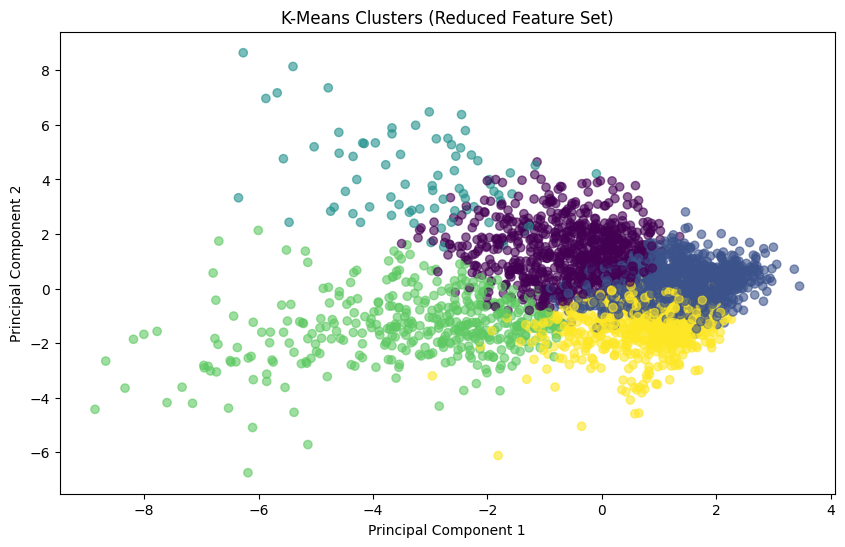

In [44]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_cluster_scaled
)

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    alpha=0.6
)

plt.title("K-Means Clusters (Reduced Feature Set)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

## Cluster Summary

In [45]:
cluster_summary = df.groupby(
    "Cluster"
)[
    [
        "target_2024_dem_vote_share",
        "higher_education_rate",
        "poverty_rate",
        "white_pct",
        "black_pct",
        "asian_pct"
    ]
].mean()

display(cluster_summary)

,target_2024_dem_vote_share,higher_education_rate,poverty_rate,white_pct,black_pct,asian_pct
Cluster,,,,,,
0,0.519676,0.211663,0.112979,0.840764,0.060308,0.020716
1,0.240604,0.149003,0.111386,0.899090,0.029583,0.006885
2,0.648136,0.317020,0.098177,0.584800,0.117421,0.150190
3,0.510491,0.120763,0.213511,0.528491,0.370424,0.009729
4,0.255400,0.108530,0.172563,0.888529,0.042695,0.004685


## K-Means Clustering Results

K-Means clustering was performed using a reduced feature set consisting of key demographic and socioeconomic variables. The Elbow Method suggested that five clusters provided a reasonable balance between model complexity and within-cluster variation.

The resulting clusters revealed several distinct county profiles. Two large clusters consisted primarily of predominantly White counties with relatively low Democratic vote share, representing different socioeconomic conditions. One cluster contained counties with higher educational attainment and more balanced voting patterns, suggesting competitive or swing counties. Another cluster was characterized by a larger Black population and higher poverty rates, while the smallest cluster contained highly educated counties with greater racial diversity and the strongest Democratic support.

Overall, the clustering analysis demonstrates that counties can be grouped into meaningful demographic and political categories based on education, poverty, racial composition, and voting behavior.

# Hierarchical Clustering

In addition to K-Means clustering, Hierarchical Clustering is applied to identify natural groupings of counties based on demographic and socioeconomic characteristics.

Unlike K-Means, Hierarchical Clustering builds a hierarchy of clusters by progressively merging similar observations. This allows us to visualize relationships between counties through a dendrogram and examine cluster structures at different levels.

The same reduced feature set used in K-Means clustering is used here to improve interpretability and avoid domination by historical election variables.

## Create Reduced Feature Dataset

In [47]:
cluster_features = [

    "higher_education_rate",
    "poverty_rate",
    "white_pct",
    "black_pct",
    "asian_pct"

]

X_hierarchical = df[cluster_features]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_hierarchical_scaled = scaler.fit_transform(
    X_hierarchical
)

print(X_hierarchical_scaled.shape)

(3063, 5)


## Hierarchical Clustering Dendrogram

A dendrogram is generated to visualize how counties merge into larger groups as clustering progresses. The dendrogram helps determine an appropriate number of clusters by identifying large vertical gaps between merges.

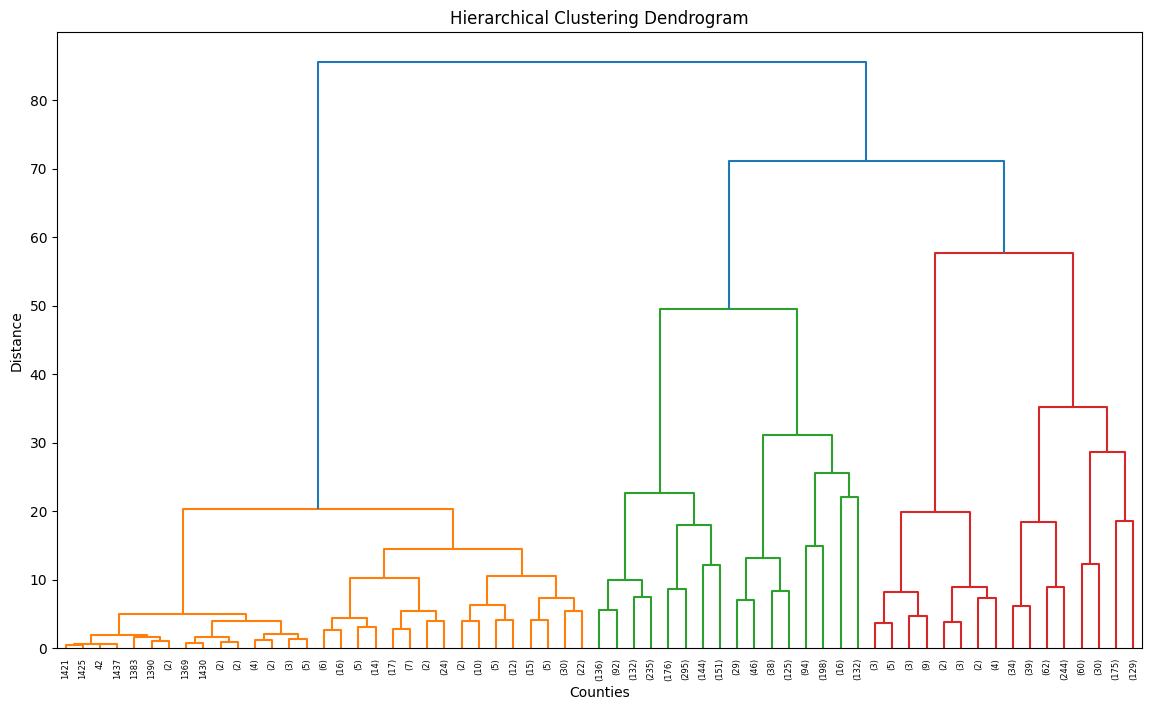

In [48]:
from scipy.cluster.hierarchy import linkage, dendrogram

import matplotlib.pyplot as plt

linked = linkage(
    X_hierarchical_scaled,
    method="ward"
)

plt.figure(figsize=(14,8))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Counties")

plt.ylabel("Distance")

plt.show()

## Create Clusters

In [51]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=5
)

hierarchical_labels = hierarchical.fit_predict(
    X_hierarchical_scaled
)

df["Hierarchical_Cluster"] = hierarchical_labels

print(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Hierarchical_Cluster
0     773
1    1361
2     678
3      31
4     220
Name: count, dtype: int64


## Hierarchical Cluster Sizes

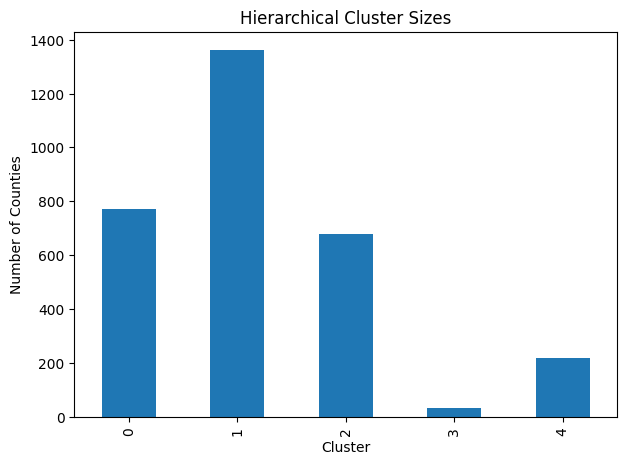

In [53]:
cluster_sizes = (
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7,5))

cluster_sizes.plot(
    kind="bar"
)

plt.title(
    "Hierarchical Cluster Sizes"
)

plt.xlabel("Cluster")

plt.ylabel("Number of Counties")

plt.show()

## PCA Visualization of Hierarchical Clusters

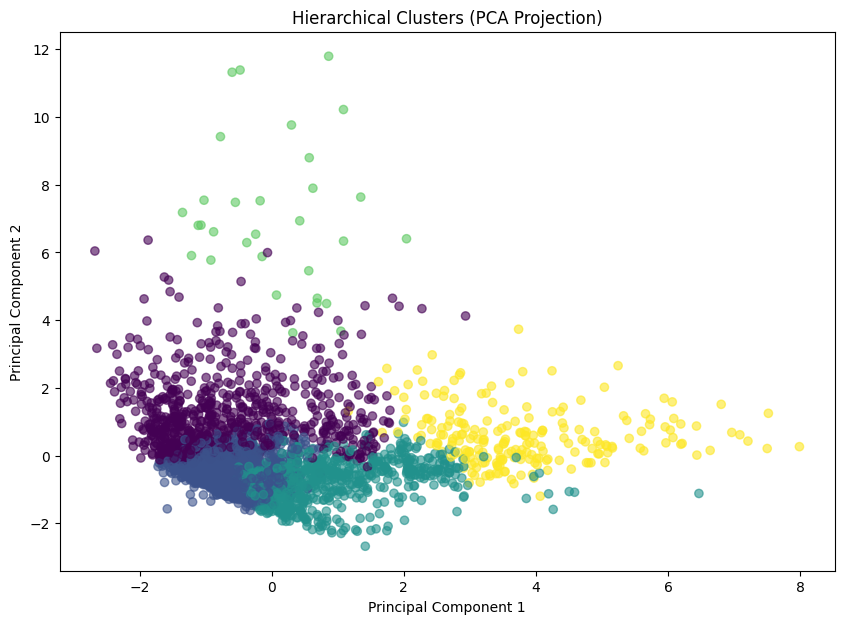

In [54]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_hierarchical_scaled
)

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hierarchical_labels,
    alpha=0.6
)

plt.title(
    "Hierarchical Clusters (PCA Projection)"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()

## Cluster Profiles

In [56]:
cluster_summary = df.groupby(
    "Hierarchical_Cluster"
)[
    [
        "target_2024_dem_vote_share",
        "higher_education_rate",
        "poverty_rate",
        "white_pct",
        "black_pct",
        "asian_pct"
    ]
].mean()

display(
    cluster_summary
)

,target_2024_dem_vote_share,higher_education_rate,poverty_rate,white_pct,black_pct,asian_pct
Hierarchical_Cluster,,,,,,
0,0.452678,0.231719,0.100477,0.820850,0.081159,0.025948
1,0.291919,0.140062,0.124386,0.916309,0.022113,0.006371
2,0.320093,0.103910,0.192079,0.778912,0.099742,0.006034
3,0.630524,0.295087,0.090832,0.489929,0.079518,0.227082
4,0.559231,0.123788,0.218784,0.455283,0.490259,0.009991


# Hierarchical Clustering Results

Hierarchical clustering was applied using the same reduced demographic feature set used for K-Means clustering. The dendrogram indicated the presence of several natural county groupings, and five clusters were selected for further analysis.

The resulting clusters revealed meaningful demographic and political patterns. One large cluster consisted primarily of heavily White counties with low Democratic vote share, while another represented poorer counties with lower educational attainment and similar Republican voting tendencies. A third cluster contained politically competitive counties with higher levels of education and more balanced electoral outcomes.

Two additional clusters captured counties with distinct demographic characteristics. One cluster was characterized by a large Black population and relatively strong Democratic support, while another contained highly educated and racially diverse counties with the highest Democratic vote shares.

The hierarchical clustering results were highly consistent with the K-Means clustering results. Both methods identified similar county profiles despite using different clustering approaches, providing additional evidence that these demographic and political groupings represent meaningful underlying structures in the county-level data.